In [1]:
import pandas as pd

In [2]:
summary_results = pd.read_csv("../summary.csv")
print(summary_results.groupby("model")[["total_time", "accuracy"]].describe().T)

model                  hydra       mrsqm
total_time count  128.000000  128.000000
           mean     9.046189   22.163786
           std     36.821275   41.329212
           min      0.042668    0.163872
           25%      0.540127    1.997131
           50%      1.653679    5.973638
           75%      6.050677   21.930829
           max    409.911766  333.811691
accuracy   count  128.000000  128.000000
           mean     0.848360    0.846887
           std      0.149701    0.143185
           min      0.324367    0.366034
           25%      0.766558    0.769005
           50%      0.892356    0.889630
           75%      0.969003    0.962646
           max      1.000000    1.000000


In [3]:
summary_results

,dataset,model,seed,n_train,n_test,series_length,n_classes,fit_time,predict_time,total_time,peak_memory_mb,accuracy,f1_macro,f1_weighted,status,error_msg
0,ACSF1,hydra,42,100,100,1460,10,2.595979,0.0,2.599249,581.697536,0.880000,0.880341,0.880341,ok,NaN
1,ACSF1,mrsqm,42,100,100,1460,10,11.948829,0.0,11.949221,-371.458048,0.930000,0.928475,0.928475,ok,NaN
2,Adiac,hydra,42,390,391,176,37,1.376490,0.0,1.377410,576.864256,0.813299,0.794570,0.798257,ok,NaN
3,Adiac,mrsqm,42,390,391,176,37,5.297851,0.0,5.298092,-310.951936,0.818414,0.808843,0.812335,ok,NaN
4,AllGestureWiimoteX,hydra,42,300,700,500,10,4.948160,0.0,4.949160,1453.113344,0.692857,0.695983,0.695983,ok,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251,Worms,mrsqm,42,181,77,900,5,9.395697,0.0,9.396166,43.646976,0.714286,0.667932,0.696970,ok,NaN
252,WormsTwoClass,hydra,42,181,77,900,2,2.046867,0.0,2.047884,0.196608,0.766234,0.762996,0.766953,ok,NaN
253,WormsTwoClass,mrsqm,42,181,77,900,2,9.326690,0.0,9.327083,42.549248,0.779221,0.777872,0.780345,ok,NaN
254,Yoga,hydra,42,300,3000,426,2,12.243240,0.0,12.244312,3277.733888,0.932667,0.932275,0.932643,ok,NaN


In [4]:
optimised_hydra = pd.read_csv("../optimised_hydra_summary.csv")
optimised_hydra.head()

,dataset,model,seed,n_train,n_test,series_length,n_classes,total_time,peak_memory_mb,accuracy,f1_macro,f1_weighted,status,error_msg,sequence_length
0,ACSF1,mps_hydra,42,100,100,1460,10,1.195224,126.042112,0.880000,0.880341,0.880341,ok,NaN,NaN
1,Adiac,mps_hydra,42,390,391,176,37,0.548068,138.723328,0.813299,0.794570,0.798257,ok,NaN,NaN
2,AllGestureWiimoteX,mps_hydra,42,300,700,500,10,1.608904,89.210880,0.690000,0.692623,0.692623,ok,NaN,NaN
3,AllGestureWiimoteY,mps_hydra,42,300,700,500,10,1.405216,0.704512,0.711429,0.708833,0.708833,ok,NaN,NaN
4,AllGestureWiimoteZ,mps_hydra,42,300,700,500,10,1.400141,0.425984,0.678571,0.674246,0.674246,ok,NaN,NaN


In [5]:
optimised_hydra = optimised_hydra[["dataset", "model", "accuracy", "total_time"]]

In [6]:
complete_results = pd.concat([summary_results[["dataset", "model", "accuracy", "total_time"]], optimised_hydra], ignore_index=True)
complete_results

,dataset,model,accuracy,total_time
0,ACSF1,hydra,0.880000,2.599249
1,ACSF1,mrsqm,0.930000,11.949221
2,Adiac,hydra,0.813299,1.377410
3,Adiac,mrsqm,0.818414,5.298092
4,AllGestureWiimoteX,hydra,0.692857,4.949160
...,...,...,...,...
507,Wine,cpu_optimised_hydra,0.888889,0.231459
508,WordSynonyms,cpu_optimised_hydra,0.744514,2.466062
509,Worms,cpu_optimised_hydra,0.740260,0.777166
510,WormsTwoClass,cpu_optimised_hydra,0.766234,0.826885


In [7]:
complete_latency_df = complete_results.pivot(index="dataset", columns="model", values="total_time").reset_index(drop=True)
complete_latency_df.rename(
    columns={
        "cpu_optimised_hydra": "CPU Opt. Hydra", 
        "mps_hydra": "MPS Opt. Hydra",
        "hydra": "Hydra",
        "mrsqm": "MrSQM"
    }, inplace=True)

In [8]:
complete_accuracy_df = complete_results.pivot(index="dataset", columns="model", values="accuracy").reset_index(drop=True)
complete_accuracy_df.rename(
    columns={
        "cpu_optimised_hydra": "CPU Opt. Hydra", 
        "mps_hydra": "MPS Opt. Hydra",
        "hydra": "Hydra",
        "mrsqm": "MrSQM"
    }, inplace=True)

In [9]:
complete_latency_df.head()

model,CPU Opt. Hydra,Hydra,MPS Opt. Hydra,MrSQM
0,0.959693,2.599249,1.195224,11.949221
1,1.279501,1.377410,0.548068,5.298092
2,1.580696,4.949160,1.608904,16.016842
3,1.567714,4.908510,1.405216,15.755030
4,1.594110,4.834126,1.400141,15.681640


In [10]:
complete_accuracy_df.head()

model,CPU Opt. Hydra,Hydra,MPS Opt. Hydra,MrSQM
0,0.880000,0.880000,0.880000,0.930000
1,0.813299,0.813299,0.813299,0.818414
2,0.690000,0.692857,0.690000,0.630000
3,0.711429,0.715714,0.711429,0.650000
4,0.678571,0.678571,0.678571,0.641429


In [11]:
C_MRSQM   = "#E69F00"   # amber
C_HYDRA   = "#0072B2"   # blue
C_POS     = "#009E73"   # green  (our result > reported)
C_NEG     = "#D55E00"   # red    (our result < reported)
C_NEUTRAL = "#999999"   # grey

In [12]:
colour_map = {
    "MPS Opt. Hydra": C_POS,
    "CPU Opt. Hydra": C_HYDRA, 
    "Hydra": C_NEUTRAL, 
    "MrSQM": C_NEUTRAL
              }
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns
import os
OUTPUT_DIR = "figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)

rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.edgecolor": "black",
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 200,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linewidth": 0.5,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.transparent": False,
})

In [13]:
def plot_baseline_distributions(df: pd.DataFrame,
                               title: str,
                               xlabel: str,
                               filename: str, 
                               clip_range=None,
                               use_log_scale=False) -> str:
    """
    Overlapping KDE plots for baseline models.
    """
    fig, ax = plt.subplots(figsize=(4.5, 3.2))  # IEEE column width
    for col, colour in colour_map.items():
        sns.kdeplot(
            df[col],
            ax=ax,
            label=col,
            color=colour,
            clip=clip_range,
            bw_adjust=0.5,
            linewidth=1.8,
            fill=True,
            alpha=0.25
        )
    if use_log_scale:
        ax.set_xscale("log")
    ax.set_xlabel(xlabel, )
    ax.set_ylabel("Density", )
    ax.set_title(title, )
    ax.legend()

    fig.tight_layout()
    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path)
    plt.show()
    plt.close(fig)

    print(f"[plot_baseline_distributions] Saved -> {path}")
    return path

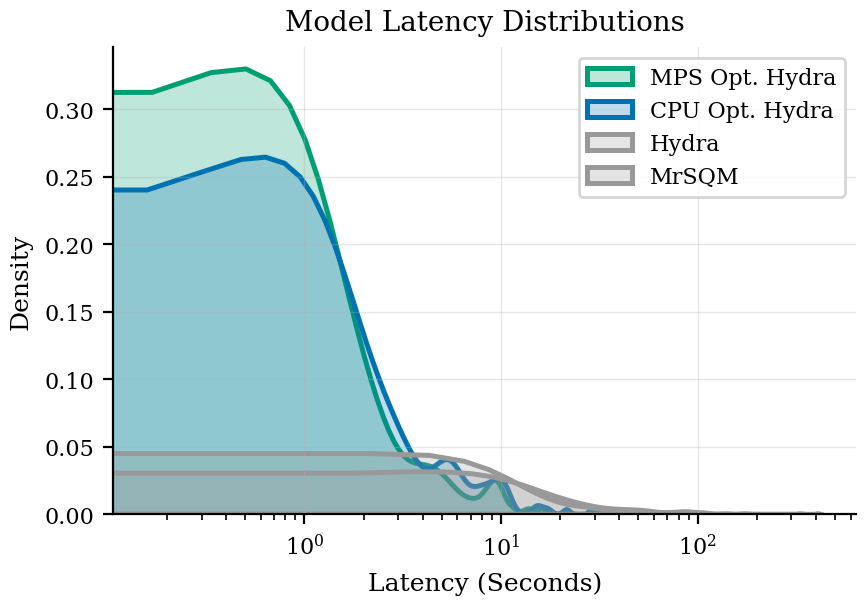

[plot_baseline_distributions] Saved -> figures/latency_distributions.png


'figures/latency_distributions.png'

In [14]:
plot_baseline_distributions(complete_latency_df,
                            title="Model Latency Distributions",
                            xlabel="Latency (Seconds)",
                            filename="latency_distributions.png",
                            clip_range=(0.0, 10000),
                            use_log_scale=True)

In [18]:
complete_latency_df.describe().T

,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
CPU Opt. Hydra,128.0,2.991095,4.551769,0.033459,0.412216,0.958394,3.234314,28.968743
Hydra,128.0,9.046189,36.821275,0.042668,0.540127,1.653679,6.050677,409.911766
MPS Opt. Hydra,128.0,2.232262,4.007369,0.044577,0.261710,0.610094,2.179562,31.152207
MrSQM,128.0,22.163786,41.329212,0.163872,1.997131,5.973638,21.930829,333.811691


In [15]:
complete_accuracy_df.describe()

model,CPU Opt. Hydra,Hydra,MPS Opt. Hydra,MrSQM
count,128.000000,128.000000,128.000000,128.000000
mean,0.848006,0.848360,0.848203,0.846887
std,0.150081,0.149701,0.149882,0.143185
min,0.324367,0.324367,0.324367,0.366034
25%,0.766558,0.766558,0.766558,0.769005
50%,0.892356,0.892356,0.892356,0.889630
75%,0.968619,0.969003,0.968619,0.962646
max,1.000000,1.000000,1.000000,1.000000


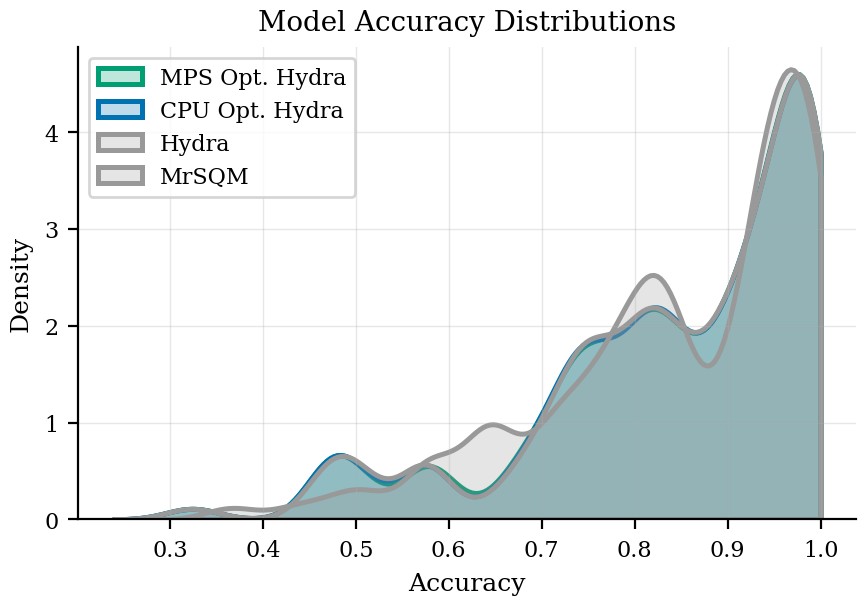

[plot_baseline_distributions] Saved -> figures/accuracy_distributions.png


'figures/accuracy_distributions.png'

In [16]:
plot_baseline_distributions(complete_accuracy_df,
                            title="Model Accuracy Distributions",
                            xlabel="Accuracy",
                            filename="accuracy_distributions.png",
                            clip_range=(0.0, 1.0))

In [17]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(df["cpu_optimised_hydra"], df["mps_hydra"])

# equality line
min_v = min(df["cpu_optimised_hydra"].min(), df["mps_hydra"].min())
max_v = max(df["cpu_optimised_hydra"].max(), df["mps_hydra"].max())
plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")

plt.xlabel("CPU Hydra Accuracy")
plt.ylabel("MPS Hydra Accuracy")
plt.title("Accuracy Comparison: CPU vs MPS Hydra")

plt.show()


NameError: name 'df' is not defined

<Figure size 1280x960 with 0 Axes>

In [ ]:
mps_hydra_results

,dataset,model,accuracy,total_time
0,ACSF1,mps_hydra,0.880000,1.192550
1,ACSF1,cpu_optimised_hydra,0.880000,1.258186
2,Adiac,mps_hydra,0.813299,0.368142
3,Adiac,cpu_optimised_hydra,0.813299,1.322123
4,AllGestureWiimoteX,mps_hydra,0.690000,1.449030
...,...,...,...,...
251,Worms,cpu_optimised_hydra,0.740260,0.812604
252,WormsTwoClass,mps_hydra,0.766234,0.769149
253,WormsTwoClass,cpu_optimised_hydra,0.766234,0.810561
254,Yoga,mps_hydra,0.932667,3.982301


In [ ]:
df = mps_hydra_results.pivot_table(index="dataset", values="total_time", columns="model").reset_index()

In [ ]:
df

model,dataset,cpu_optimised_hydra,mps_hydra
0,ACSF1,1.258186,1.192550
1,Adiac,1.322123,0.368142
2,AllGestureWiimoteX,1.691959,1.449030
3,AllGestureWiimoteY,1.688624,1.411153
4,AllGestureWiimoteZ,1.683027,1.407797
...,...,...,...
123,Wine,0.085702,0.172740
124,WordSynonyms,0.876407,0.739555
125,Worms,0.812604,0.866048
126,WormsTwoClass,0.810561,0.769149


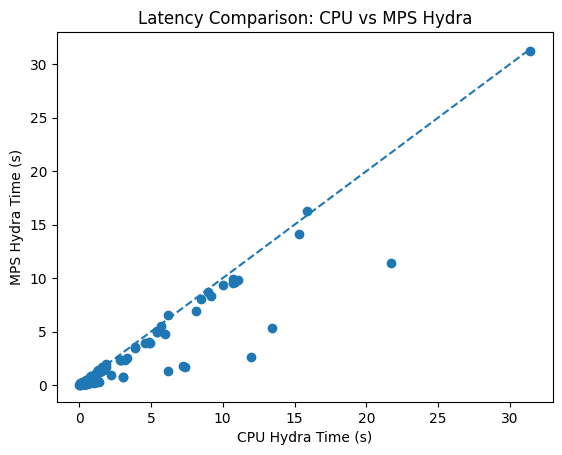

In [ ]:
plt.figure()

plt.scatter(df["cpu_optimised_hydra"], df["mps_hydra"])

min_v = min(df["cpu_optimised_hydra"].min(), df["mps_hydra"].min())
max_v = max(df["cpu_optimised_hydra"].max(), df["mps_hydra"].max())

plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")

plt.xlabel("CPU Hydra Time (s)")
plt.ylabel("MPS Hydra Time (s)")
plt.title("Latency Comparison: CPU vs MPS Hydra")

plt.show()


In [ ]:
df = mps_hydra_results.pivot_table(index="dataset", values="accuracy", columns="model").reset_index()

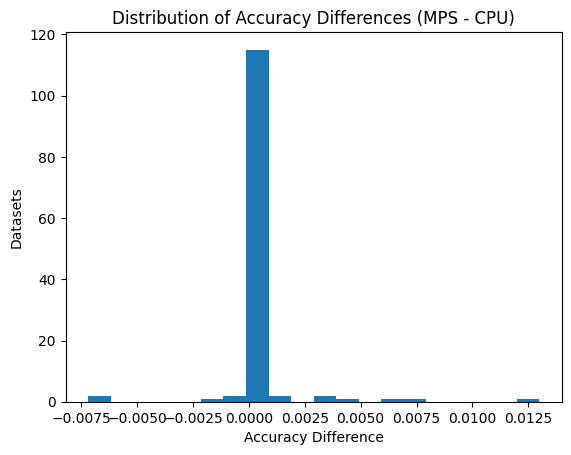

In [ ]:
df["accuracy_diff"] = df["mps_hydra"] - df["cpu_optimised_hydra"]

plt.figure()

plt.hist(df["accuracy_diff"], bins=20)

plt.title("Distribution of Accuracy Differences (MPS - CPU)")
plt.xlabel("Accuracy Difference")
plt.ylabel("Datasets")

plt.show()


In [ ]:
df = mps_hydra_results.pivot_table(index="dataset", values="total_time", columns="model").reset_index()

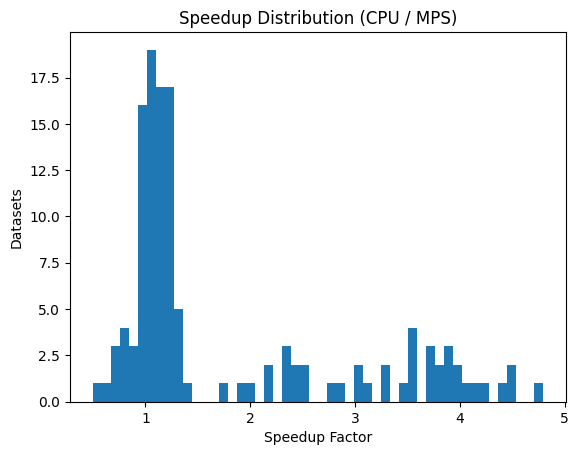

In [ ]:
df["speedup"] = df["cpu_optimised_hydra"] / df["mps_hydra"]

plt.figure()

plt.hist(df["speedup"], bins=50)


plt.title("Speedup Distribution (CPU / MPS)")
plt.xlabel("Speedup Factor")
plt.ylabel("Datasets")

plt.show()


In [ ]:
from scipy.stats import wilcoxon

stat, p = wilcoxon(df["cpu_optimised_hydra"], df["mps_hydra"])

print("Latency Wilcoxon p-value:", p)


Latency Wilcoxon p-value: 2.6047164661491603e-16


In [ ]:
df = mps_hydra_results.pivot_table(index="dataset", values="accuracy", columns="model").reset_index()

In [ ]:
stat, p = wilcoxon(df["cpu_optimised_hydra"], df["mps_hydra"])

print("Latency Wilcoxon p-value:", p)


Latency Wilcoxon p-value: 0.221330082993901


In [ ]:
df["sequence_length"] = summary_results["series_length"] * summary_results["n_test"]

In [ ]:
plt.figure()

plt.scatter(df["sequence_length"], df["speedup"])

plt.xlabel("Sequence Length")
plt.ylabel("Speedup (CPU/MPS)")
plt.title("Speedup vs Sequence Length")

plt.show()


KeyError: 'speedup'

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.scatter(df["train_size"], df["speedup"])


KeyError: 'train_size'

In [ ]:
differences = hydra_results[["dataset"]].copy()
differences["accuracy"] = hydra_results["accuracy"] - mps_hydra_results["accuracy"]
differences["total_time"] = hydra_results["total_time"] - mps_hydra_results["total_time"]



,dataset,accuracy,total_time
0,ACSF1,0.000000,1.380905
1,Adiac,0.000000,1.008519
2,AllGestureWiimoteX,0.002857,3.502055
3,AllGestureWiimoteY,0.004286,3.468970
4,AllGestureWiimoteZ,0.000000,3.398578
...,...,...,...
123,Wine,0.000000,0.019888
124,WordSynonyms,0.000000,1.637132
125,Worms,0.000000,1.075961
126,WormsTwoClass,0.000000,1.267726


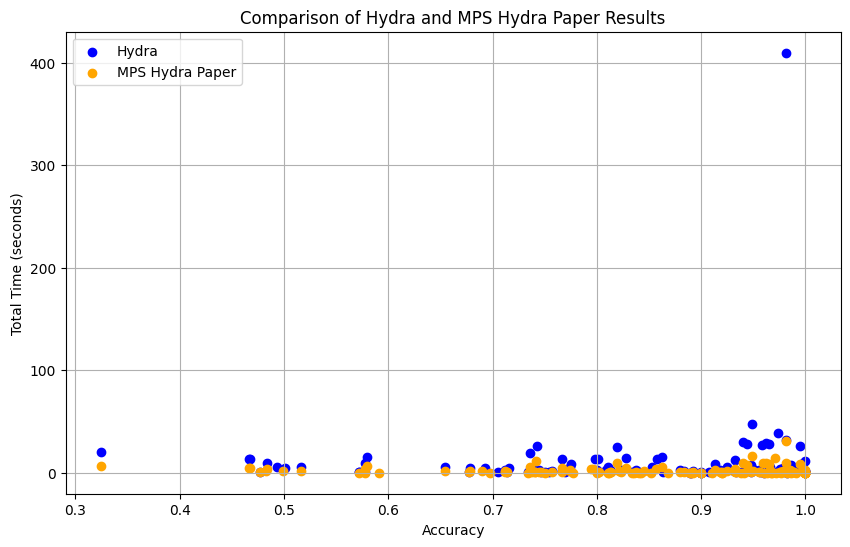

In [ ]:
# Plot a scatter plot of the accuracy of each and the total time of each, with the x axis being the accuracy and the y axis being the total time, and color the points by the dataset.
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(hydra_results["accuracy"], hydra_results["total_time"], color="blue", label="Hydra")
plt.scatter(mps_hydra_results["accuracy"], mps_hydra_results["total_time"], color="orange", label="MPS Hydra Paper")
plt.xlabel("Accuracy")
plt.ylabel("Total Time (seconds)")
plt.title("Comparison of Hydra and MPS Hydra Paper Results")
plt.legend()
plt.grid()
plt.show()

In [ ]:
def load_data() -> pd.DataFrame:
    """
    Load the accuracy results into a tidy DataFrame and add derived columns.

    Returns
    -------
    df : pd.DataFrame
        Columns: dataset, mrsqm, hydra, mrsqm_reported, hydra_reported,
                 mrsqm_diff, hydra_diff,
                 my_winner, rep_winner, rank_agrees
    """

    summary_results = pd.read_csv("summary.csv")
    print(summary_results.groupby("model")[["total_time", "accuracy"]].describe().T)

    results_mps_hydra_paper = pd.read_csv("mps_hydra_summary.csv")

    print(results_mps_hydra_paper[["accuracy"]].describe().T)

    mrsqm_accuracy = summary_results[summary_results["model"] == "mrsqm"][["dataset", "accuracy"]]
    mrsqm_accuracy.rename(columns={"accuracy": "mrsqm"}, inplace=True)
    hydra_accuracy = summary_results[summary_results["model"] == "hydra"][["dataset", "accuracy"]]
    hydra_accuracy.rename(columns={"accuracy": "hydra"}, inplace=True)

    mrsqm_reported = results_mrsqm_paper[["Dataset", "MrSQM_SFA_k5"]].copy()
    mrsqm_reported.rename(columns={"MrSQM_SFA_k5": "mrsqm_reported"}, inplace=True)
    mrsqm_reported.rename(columns={"Dataset": "dataset"}, inplace=True)
    hydra_reported = results_hydra_paper[["dataset", "accuracy"]].copy()
    hydra_reported.rename(columns={"accuracy": "hydra_reported"}, inplace=True)

    comparison_df = mrsqm_accuracy.merge(hydra_accuracy, on="dataset").merge(mrsqm_reported, on="dataset").merge(hydra_reported, on="dataset")
    print(comparison_df)

    comparison_df["mrsqm_diff"] = comparison_df["mrsqm"] - comparison_df["mrsqm_reported"]
    comparison_df["hydra_diff"]  = comparison_df["hydra"]  - comparison_df["hydra_reported"]

    def winner(a, b):
        if a > b:   return "mrsqm"
        if b > a:   return "hydra"
        return "tie"

    comparison_df["my_winner"]   = comparison_df.apply(lambda r: winner(r.mrsqm,          r.hydra),          axis=1)
    comparison_df["rep_winner"]  = comparison_df.apply(lambda r: winner(r.mrsqm_reported, r.hydra_reported), axis=1)
    comparison_df["rank_agrees"] = comparison_df["my_winner"] == comparison_df["rep_winner"]
    return comparison_df